# EDA Fase 2: Análisis Temporal y Climático
Este notebook aborda la primera parte del Análisis Exploratorio de Datos (EDA).
El objetivo es identificar las ventanas críticas de ignición cruzando la distribución temporal de los incendios con las condiciones meteorológicas extremas (Regla del 30-30-30).

**Decisiones Metodológicas:**
1. Transformación Logarítmica (`log1p`) aplicada a la superficie quemada para estabilizar la varianza extrema (leyes de potencia).
2. Conservación de Grandes Incendios Forestales (GIFs > 500ha) como eventos de máximo riesgo.
3. Exportación automática de figuras en alta resolución a `/entregas/figuras/`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

FIG_DIR = Path("../entregas/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../datos/processed/07_dataset_final_TOPOGRAFICO.csv', sep=';', decimal=',') 
df = df.drop_duplicates(subset=['lat', 'lon', 'fecha_ini', 'Superficie_Total_Real'])

cols_numericas = ['Superficie_Total_Real', 'temp_max', 'racha_max', 'temp_media', 'temp_min', 'precipitacion', 'humedad_media', 'viento_medio', 'pendiente', 'orientacion']
for col in cols_numericas:
    if col in df.columns:
        
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

df['fecha_ini'] = pd.to_datetime(df['fecha_ini'])
df['mes'] = df['fecha_ini'].dt.month
df['año'] = df['fecha_ini'].dt.year

meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
df['mes_nombre'] = df['mes'].apply(lambda x: meses_es[int(x)-1] if not pd.isna(x) else 'Desconocido')

df['log_superficie'] = np.log1p(df['Superficie_Total_Real'])

df['es_GIF'] = df['Superficie_Total_Real'] > 500
print(f"Dataset cargado con {len(df)} registros.")
print(f"Total de Grandes Incendios Forestales (GIFs): {df['es_GIF'].sum()}")


Dataset cargado con 4476 registros.
Total de Grandes Incendios Forestales (GIFs): 19


## 1. Análisis de Temporalidad Base
Distribución mensual de los incendios y superficie quemada.


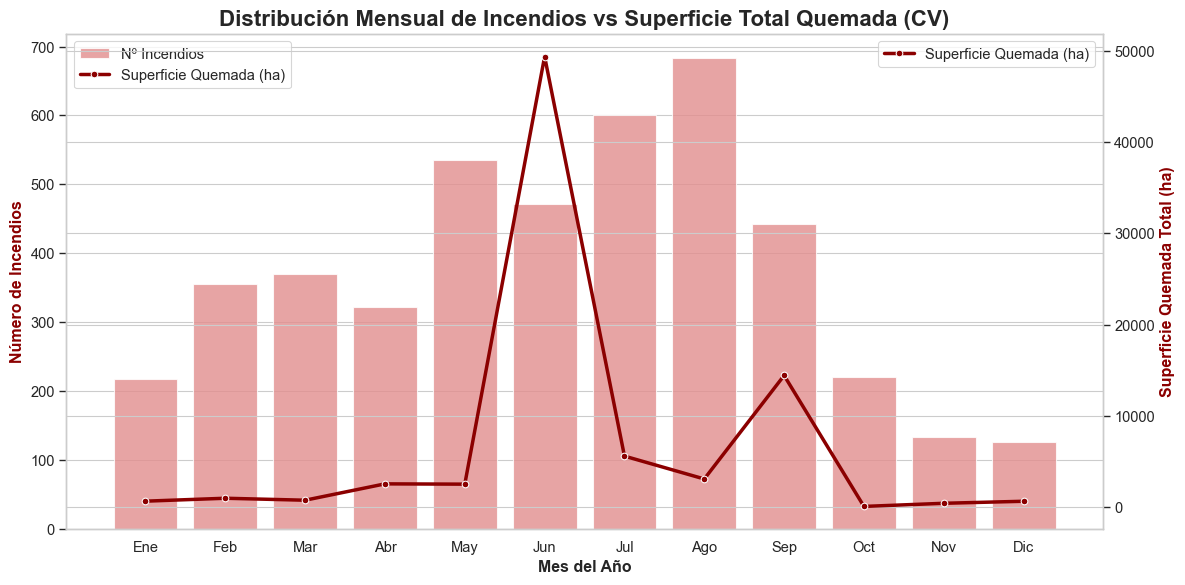

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))


mes_stats = df.dropna(subset=['mes']).groupby('mes').agg(
    conteo=('Campania', 'count'),
    superficie_total=('Superficie_Total_Real', 'sum')
).reset_index()


sns.barplot(data=mes_stats, x='mes', y='conteo', color='lightcoral', alpha=0.8, ax=ax1, label='Nº Incendios')
ax1.set_ylabel('Número de Incendios', color='darkred', fontweight='bold')
ax1.set_xlabel('Mes del Año', fontweight='bold')
ax1.set_xticks(range(12))
ax1.set_xticklabels(meses_es)


ax2 = ax1.twinx()

sns.lineplot(data=mes_stats, x=mes_stats.index, y='superficie_total', color='darkred', marker='o', linewidth=2.5, ax=ax2, label='Superficie Quemada (ha)')
ax2.set_ylabel('Superficie Quemada Total (ha)', color='darkred', fontweight='bold')

plt.title('Distribución Mensual de Incendios vs Superficie Total Quemada (CV)', fontsize=16, fontweight='bold')


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_Distribucion_Mensual_Incendios.png', dpi=300, bbox_inches='tight')
plt.show()


### Gráfico de Radar (Estacionalidad)


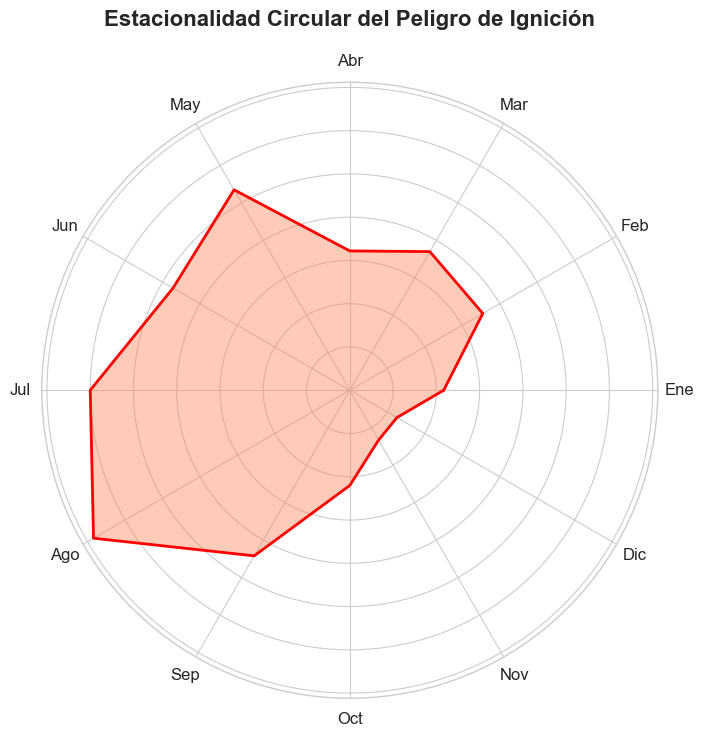

In [4]:

angles = np.linspace(0, 2 * np.pi, 12, endpoint=False).tolist()
angles += angles[:1] 

valores = mes_stats['conteo'].tolist()
valores += valores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, valores, color='coral', alpha=0.4)
ax.plot(angles, valores, color='red', linewidth=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(meses_es, fontsize=12)
ax.set_yticklabels([]) 
plt.title('Estacionalidad Circular del Peligro de Ignición', fontsize=16, fontweight='bold', pad=20)

plt.savefig(FIG_DIR / '02_Radar_Estacionalidad.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Cruce Termo-Eólico (Ventanas Críticas)
Vamos a explorar las variables meteorológicas extremas (`temp_max` y `racha_max`) para evidenciar empíricamente la "Regla 30-30" (Temperatura > 30ºC, Viento > 30km/h).


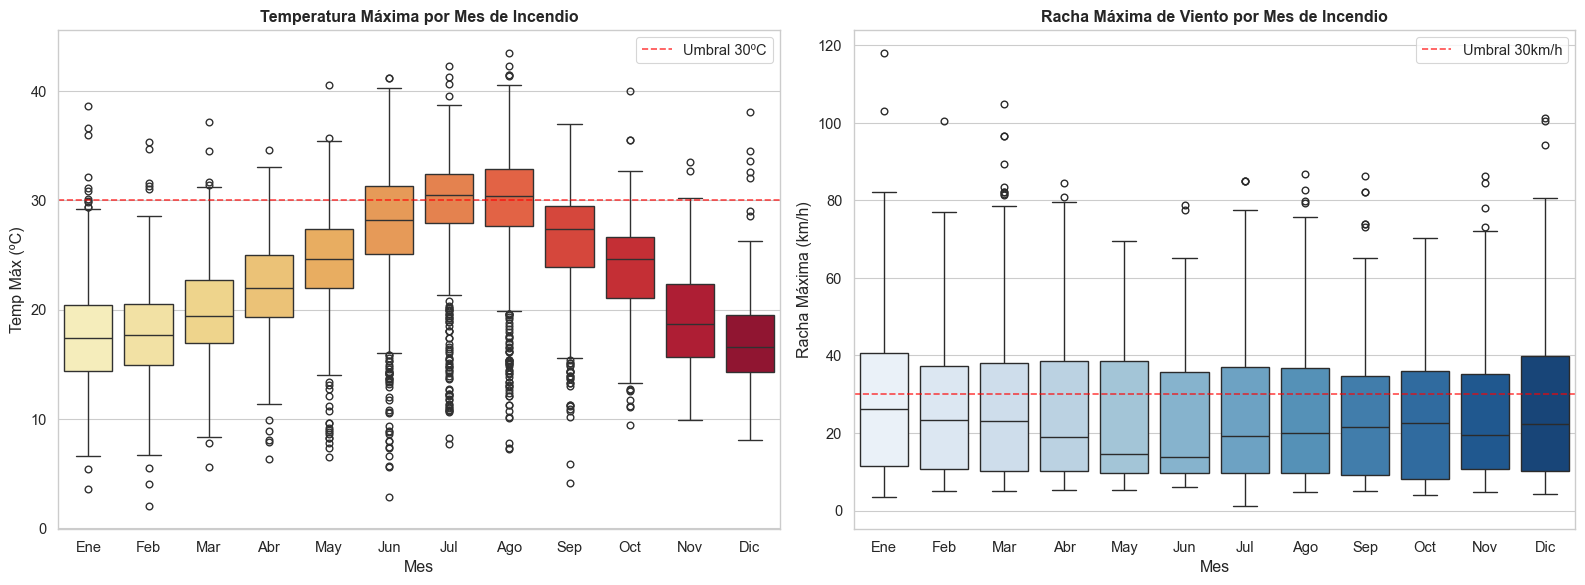

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df.dropna(subset=['mes']), x='mes', y='temp_max', ax=axes[0], palette='YlOrRd')
axes[0].set_xticklabels(meses_es)
axes[0].set_title('Temperatura Máxima por Mes de Incendio', fontweight='bold')
axes[0].set_ylabel('Temp Máx (ºC)')
axes[0].set_xlabel('Mes')
axes[0].axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Umbral 30ºC')
axes[0].legend()

sns.boxplot(data=df.dropna(subset=['mes']), x='mes', y='racha_max', ax=axes[1], palette='Blues')
axes[1].set_xticklabels(meses_es)
axes[1].set_title('Racha Máxima de Viento por Mes de Incendio', fontweight='bold')
axes[1].set_ylabel('Racha Máxima (km/h)')
axes[1].set_xlabel('Mes')
axes[1].axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Umbral 30km/h')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '03_Boxplots_Climatologicos_Mensuales.png', dpi=300, bbox_inches='tight')
plt.show()


### KDE / Hexbin: La Regla 30-30-30 en la Comunitat Valenciana
Análisis bidimensional para ver la concentración del riesgo según Temperatura vs Viento, usando la superficie en escala logarítmica para ponderar el color.


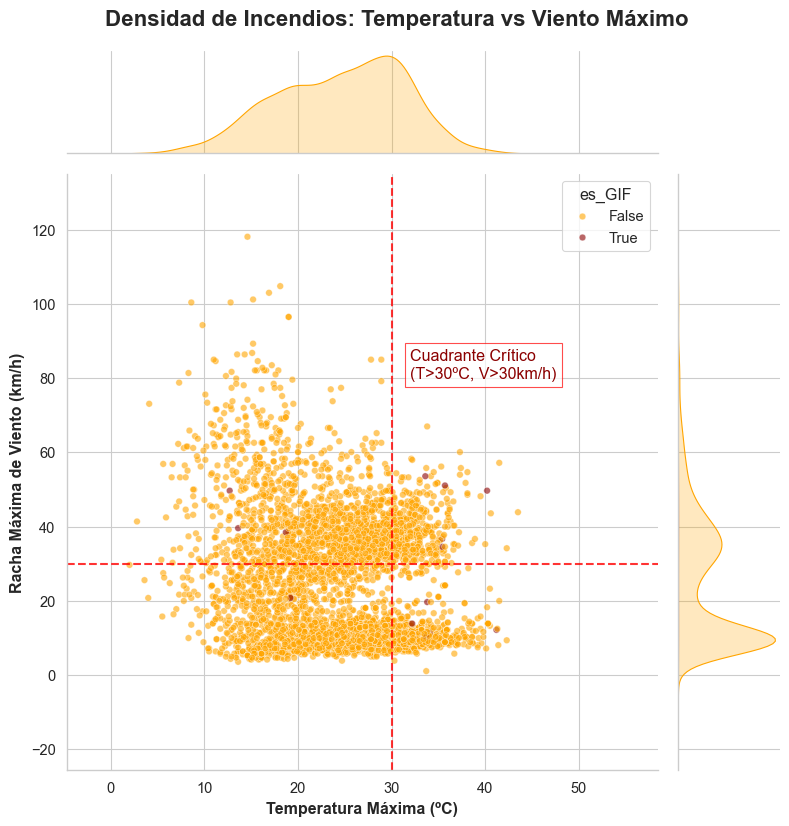

In [6]:

df_clima = df.dropna(subset=['temp_max', 'racha_max', 'log_superficie']).copy()


g = sns.jointplot(
    data=df_clima, 
    x="temp_max", 
    y="racha_max", 
    hue="es_GIF",
    palette={False: "orange", True: "darkred"},
    alpha=0.6,
    height=8,
    marginal_kws=dict(fill=True)
)

g.fig.suptitle('Densidad de Incendios: Temperatura vs Viento Máximo', fontweight='bold', fontsize=16, y=1.03)
g.ax_joint.set_xlabel('Temperatura Máxima (ºC)', fontweight='bold')
g.ax_joint.set_ylabel('Racha Máxima de Viento (km/h)', fontweight='bold')


g.ax_joint.axvline(x=30, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
g.ax_joint.axhline(y=30, color='red', linestyle='--', linewidth=1.5, alpha=0.8)


g.ax_joint.text(32, 80, 'Cuadrante Crítico\n(T>30ºC, V>30km/h)', color='darkred', 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))

plt.savefig(FIG_DIR / '04_JointPlot_Clima_Extremo.png', dpi=300, bbox_inches='tight')
plt.show()


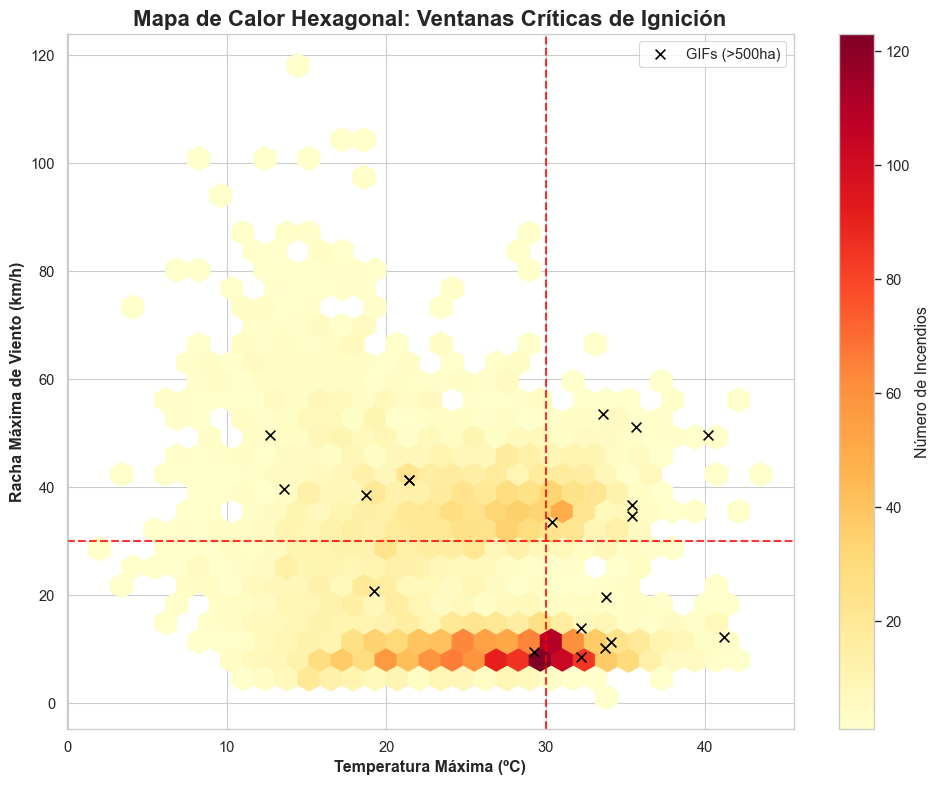

In [7]:

plt.figure(figsize=(10, 8))
hb = plt.hexbin(df_clima['temp_max'], df_clima['racha_max'], gridsize=30, cmap='YlOrRd', mincnt=1)
cb = plt.colorbar(hb)
cb.set_label('Número de Incendios')

plt.title('Mapa de Calor Hexagonal: Ventanas Críticas de Ignición', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura Máxima (ºC)', fontweight='bold')
plt.ylabel('Racha Máxima de Viento (km/h)', fontweight='bold')


plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=30, color='red', linestyle='--', linewidth=1.5, alpha=0.8)


gifs = df_clima[df_clima['es_GIF'] == True]
plt.scatter(gifs['temp_max'], gifs['racha_max'], color='black', marker='x', s=50, label='GIFs (>500ha)')
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_Hexbin_Riesgo_Climatico.png', dpi=300, bbox_inches='tight')
plt.show()
